In [1]:
import numpyro as py
import numpyro.distributions as dist
import jax.random as rn
key = rn.PRNGKey(1)
import seaborn as sns
import pandas as pd
from numpyro.infer import MCMC, NUTS
from jax import numpy as jnp
import jax
import cme.simulators.diffusion_random_walk as drw
import numpy as np

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
jax.local_device_count()

1

In [3]:
py.set_host_device_count(4)

<Axes: ylabel='Density'>

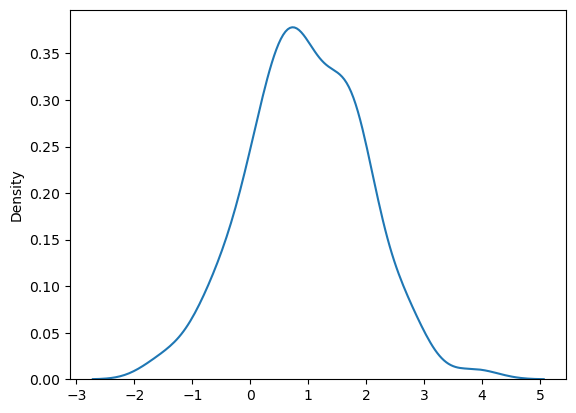

In [4]:
sns.kdeplot(dist.Normal(1,1).sample(key, (100,)))

In [6]:
theta, alpha, tau, sigma = 100, 1.5, 0.01, 1
mu = np.asarray([[0.2]])
states = drw.get_transition_matrix(alpha, tau,sigma=sigma, params=mu, process="Wiener",n_states = theta)
states

array([[0.33333333, 0.34      , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.32666667, 0.33333333, 0.34      , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.32666667, 0.33333333, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.33333333, 0.34      ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.32666667, 0.33333333,
        0.34      ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.32666667,
        0.33333333]])

In [ ]:
def diffusion_accuracy(I, X=None):
    m = py.sample("m", dist.Normal(1,1), sample_shape=(3,1))
    s = py.sample("s", dist.Normal(1,0.02), sample_shape=(3,1))
    
    a_pr = py.sample("a", dist.Normal(1,1))
    v_pr = py.sample("v", dist.Normal(1,1))
    z_pr = py.sample("z", dist.Normal(1,1))

    a = m[0] + s[0]*a_pr
    v = m[1] + s[1]*v_pr
    z = m[2] + s[2]*z_pr

    #(1 / a*a) * (jnp.exp( (-z*a*v) - (v*v * DT)/2 ))
    p = (jnp.exp(-2*a*v) - 1) / (jnp.exp(-2*z*v) - 1)
    py.sample("X", dist.Bernoulli(p), obs=X)
    

In [ ]:
import numpy as np
np.random.randint(0,2,(10, 2))

In [ ]:
n_kernel = NUTS(diffusion_accuracy)
mcmc = MCMC(n_kernel, num_warmup=500, num_samples=1500, num_chains=4)
X = np.random.randint(0,2,(10, 2))
mcmc.run(key, 10,X)

In [ ]:
mcmc.print_summary()